### 2.1.2 径向基函数

给定设计点集合 $D = \{\boldsymbol{x}_1, \dots, \boldsymbol{x}_n\}$ 以及对应的函数观测值 $y_i = h(\boldsymbol{x}_i)$（$i = 1, \dots, n$），我们希望构造如下形式的插值函数：$$h_n(\boldsymbol{x}) = \sum_{i=1}^{n} \beta_i R_i(\boldsymbol{x})$$ 式中 $R_i(\boldsymbol{x})$ 为关于变量 $\boldsymbol{x}$ 的一组基函数，$i = 1, \dots, n$。针对一维多项式插值，我们选取基函数 $R_1(x) = 1, R_2(x) = x, \dots, R_n(x) = x^{n-1}$。但迈尔胡伯-柯蒂斯定理（法斯豪尔，2007，第3页）指出：当维度 $p\ge2$ 时，无法预先选定固定的基函数集合，对 $\mathbb{R}^p$ 中任意散乱数据完成插值。这意味着基函数必须依赖于数据采样点。据此令：$$R_i(\boldsymbol{x}) = R(\boldsymbol{x} - \boldsymbol{x}_i)$$ 其中映射关系为 $R: \mathbb{R}^p \to \mathbb{R}$。

插值条件可推导出如下 $n$ 个方程 $$\sum_{j=1}^{n}\beta_j R(\boldsymbol{x}_i -\boldsymbol{x}_j) = y_i,\quad i = 1, \dots, n$$ 写成矩阵形式，该方程组可表示为 $\boldsymbol{R}\boldsymbol{\beta} = \boldsymbol{y}$。其中 $\boldsymbol{R}$ 为 $n$ 阶方阵，其第 $i$ 行第 $j$ 列元素为 $R(\boldsymbol{x}_i-\boldsymbol{x}_j)$；$\boldsymbol{\beta}=(\beta_1, \dots, \beta_n)'$，$\boldsymbol{y}=(y_1, \dots, y_n)'$。若矩阵 $\boldsymbol{R}$ 非奇异，则可求得唯一解 $\hat{\boldsymbol{\beta}} = \boldsymbol{R}^{-1}\boldsymbol{y}$，由此得到径向基函数插值器：$$\hat{y}(\boldsymbol{x}) = \boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{y} \tag{2.6}$$ 式中 $\boldsymbol{r}(\boldsymbol{x})$ 是 $n\times1$ 维向量，其第 $i$ 个分量为 $R(\boldsymbol{x}-\boldsymbol{x}_i)$。当 $p=1$ 时，该插值器与式 (2.4) 中的多项式插值形式完全一致，区别仅在于此处采用径向基函数替代多项式基函数。但与多项式插值不同的是，径向基函数插值适用于任意 $p$ 值，且对设计集 $D$ 无结构要求。

在继续深入分析之前，我们需要解答一个关键问题：对于任意形式的函数 $R(\cdot)$ 与任意试验设计 $D$，矩阵 $\boldsymbol{R}$ 是否都是可逆矩阵？目前尚未明确能使矩阵 $\boldsymbol{R}$ 可逆的 $R(\cdot)$ 所需满足的严格数学条件。不过，学界已经得出可令矩阵 $\boldsymbol{R}$ 成为正定矩阵的 $R(\cdot)$ 判定条件，而正定矩阵必然可逆。想要完成推导，我们需要先理解正定函数这一概念（法斯豪尔，2007，第 3 章）。

> **定义 2.1** 若对于任意设计 $D = \{\boldsymbol{x}_1, \dots, \boldsymbol{x}_n\}$ 以及任意向量 $\boldsymbol{c} = (c_1, \dots, c_n)'$，均满足 $$\sum_{i=1}^{n}\sum_{j=1}^{n}c_ic_jR(\boldsymbol{x}_i - \boldsymbol{x}_j) \ge 0 \tag{2.7}$$ 则称连续函数 $R: \mathbb{R}^p \to \mathbb{R}$ 在 $\mathbb{R}^p$ 上半正定。若式 (2.7) 仅在 $\boldsymbol{c}=\boldsymbol{0}$ 时取等号，则称函数 $R(\cdot)$ 正定。

因此，若选取 $R(\cdot)$ 为正定函数，那么只要数据节点 $\boldsymbol{x}_1,\dots,\boldsymbol{x}_n$ 互不相同，$\boldsymbol{R}$ 便是可逆矩阵。径向基函数（RBF）相关文献进一步限定 $R(\cdot)$ 为径向函数（法斯豪尔，2007，第 2 章）。

> **定义 2.2** 若存在函数 $\psi: \mathbb{R}^+ \to \mathbb{R}$，使得 $R(\boldsymbol{x}) = \psi(\|\boldsymbol{x}\|)$（其中 $\|\cdot\|$ 一般为欧几里得范数），则称函数 $R: \mathbb{R}^p \to \mathbb{R}$ 为径向函数。

径向基函数存在多种可选类型，详细内容可参阅法斯豪尔 2007 年所著书籍。高斯函数便是其中一例：$$R(\boldsymbol{x}) = \exp\left(-\frac{\|\boldsymbol{x}\|^2}{\theta^2}\right) \tag{2.8}$$ 本书会频繁用到该函数。此函数包含一个未知参数 $\theta$（称作长度尺度），需要结合数据进行调参，以此实现良好的预测效果。

再次回顾式 (2.1) 中的一维算例。取区间 $[0,1]$ 内 $n=10$ 个等距节点构成集合 $D$，即 $D=\{(i-1)/(n-1)\}_{i=1}^n$。选取式 (2.8) 中的高斯函数作为径向基函数。图 2.3 展示了三组不同 $\theta$ 取值下的径向基函数插值结果。不难发现，当 $\theta=0.1$ 时径向基插值效果十分理想；$\theta=1$ 时插值效果欠佳（表现与图 2.1 左子图相近）；而 $\theta=0.01$ 时插值效果极差。总而言之，径向基函数插值具备极强的灵活性，能够实现高精度插值，但随之带来额外的难点：需要合理调节径向基函数中的尺度参数。

> **图 2.3** 采用 10 个等间距采样点，并为高斯径向基函数选取三组不同 $\theta$ 参数的径向基函数插值法。

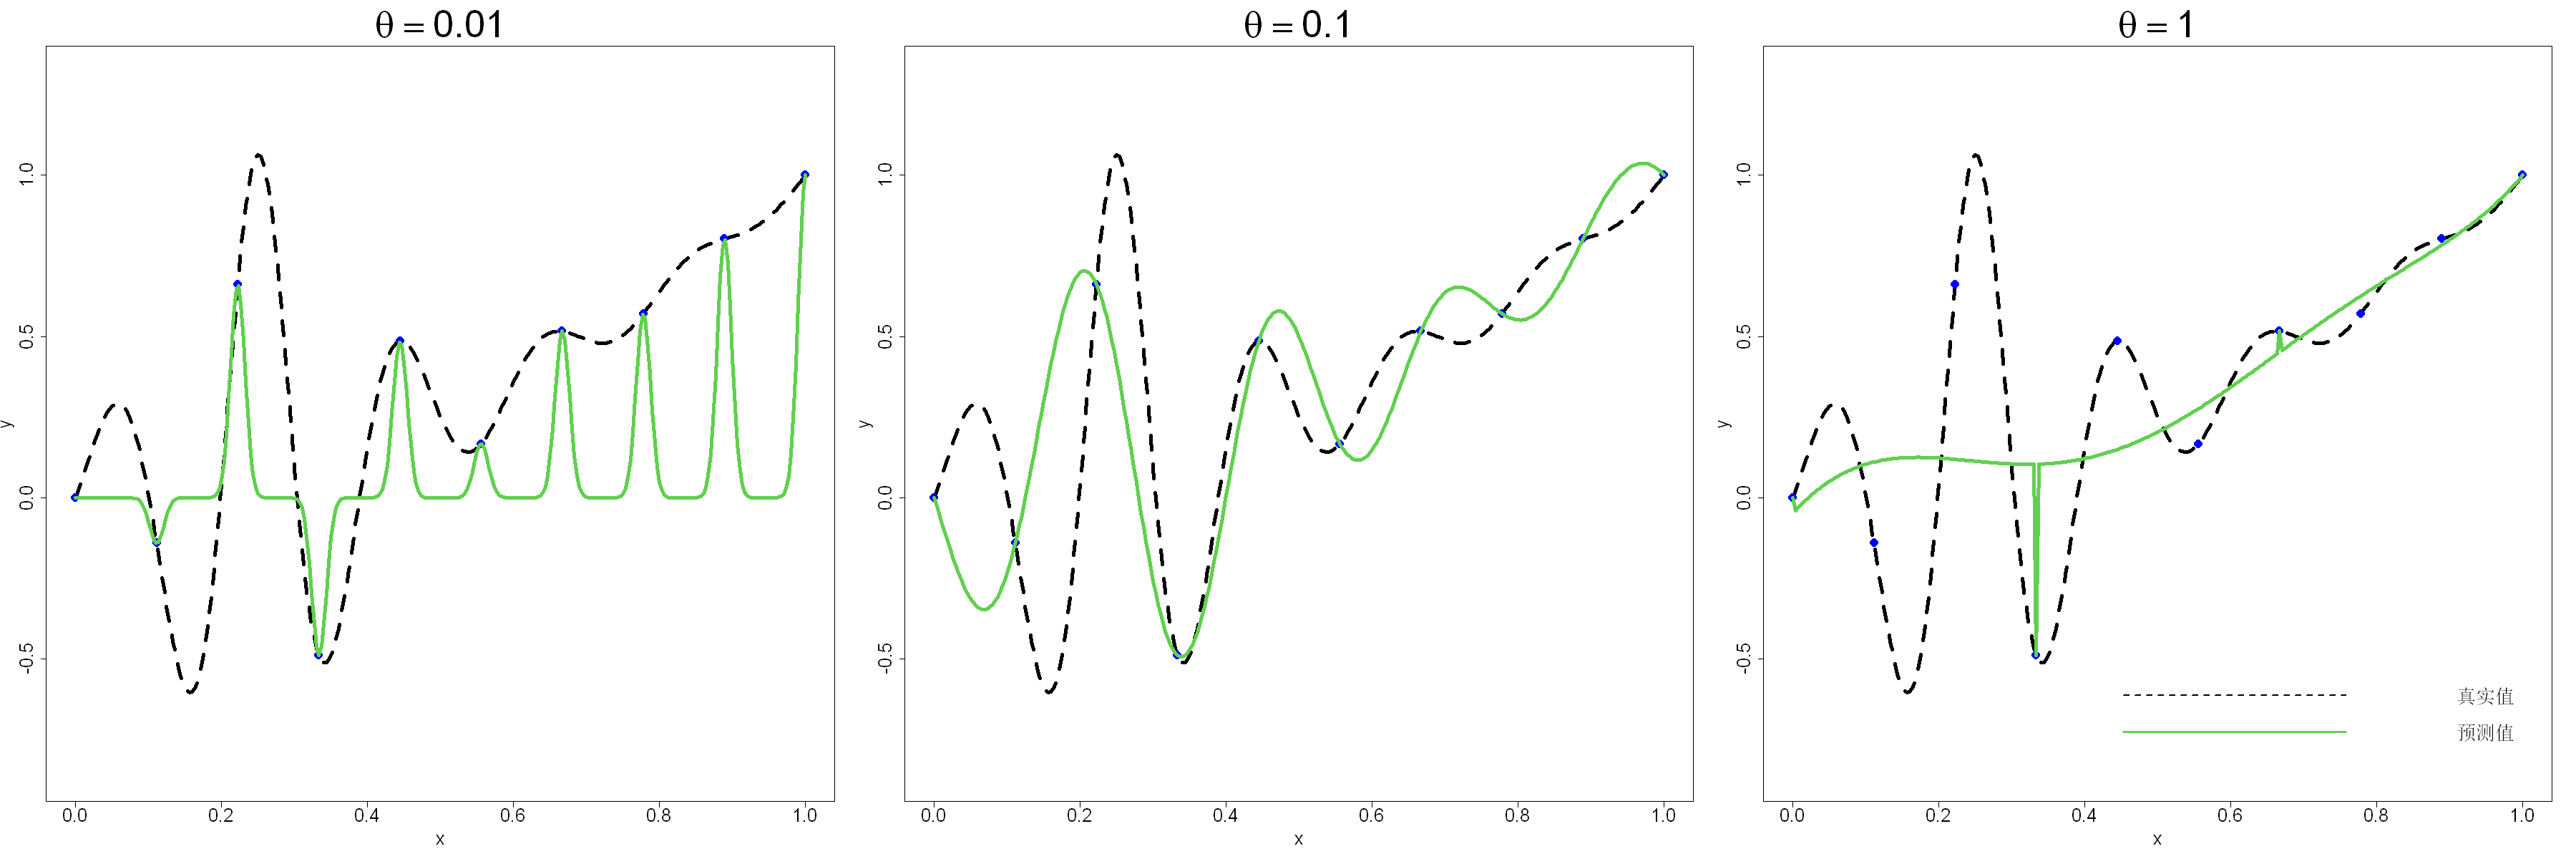

In [12]:
# 图 2.3

options(repr.plot.width=30,repr.plot.height=10)
library(DiceKriging)
par(mfrow=c(1,3))
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=matrix(seq(0,1,length=301),ncol=1,dimnames=list(NULL,"x"))
true=f(test[,1])
n=10
D=matrix(((1:n)-1)/(n-1),ncol=1,dimnames=list(NULL,"x"))
y=f(D[,1])

theta=.01
km.model=km(~1,design=D,response=y,covtype="gauss",coef.cov=theta,coef.var=1,coef.trend=0,penalty=FALSE,nugget=1e-8,nugget.estim=FALSE,control=list(trace=FALSE))
pred=predict(km.model,test,type="SK")$mean
plot(test[,1],true,type="l",lwd=4,lty=2,xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main=expression(theta==0.01),cex.main=4,cex.lab=2,cex.axis=2)
points(D[,1],y,pch=16,cex=2,col="blue")
lines(test[,1],pred,col=3,lwd=4)

theta=.1
km.model=km(~1,design=D,response=y,covtype="gauss",coef.cov=theta,coef.var=1,coef.trend=0,penalty=FALSE,nugget=1e-8,nugget.estim=FALSE,control=list(trace=FALSE))
pred=predict(km.model,test,type="SK")$mean
plot(test[,1],true,type="l",lwd=4,lty=2,xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main=expression(theta==0.1),cex.main=4,cex.lab=2,cex.axis=2)
points(D[,1],y,pch=16,cex=2,col="blue")
lines(test[,1],pred,col=3,lwd=4)

theta=1
km.model=km(~1,design=D,response=y,covtype="gauss",coef.cov=theta,coef.var=1,coef.trend=0,penalty=FALSE,nugget=1e-8,nugget.estim=FALSE,control=list(trace=FALSE))
pred=predict(km.model,test,type="SK")$mean
plot(test[,1],true,type="l",lwd=4,lty=2,xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main=expression(theta==1),cex.main=4,cex.lab=2,cex.axis=2)
points(D[,1],y,pch=16,cex=2,col="blue")
lines(test[,1],pred,col=3,lwd=4)
legend(.3,-.5,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(2,3),bty="n",cex=2)
par(mfrow=c(1,1))

调节径向基函数长度尺度参数的一种方法是采用交叉验证。留一交叉验证误差的表达式为：$$cv_i = y_i −\hat{y}_{\sim i}(\boldsymbol{x}_i)$$ 式中 $\hat{y}_{\sim i}(\boldsymbol{x}_i)$ 代表舍弃第 $i$ 组数据点后，由径向基插值模型在 $\boldsymbol{x}=\boldsymbol{x}_i$ 位置得到的预测值。由此可得 $\hat{y}_{\sim i}(\boldsymbol{x}_i) = \boldsymbol{r}_{\sim i}(\boldsymbol{x}_i)'(\boldsymbol{R}_{\sim i})^{-1}\boldsymbol{y}_{\sim i}$，其中 $\boldsymbol{r}_{\sim i}$ 表示向量 $\boldsymbol{r}$ 剔除第 $i$ 个元素后的向量（$\boldsymbol{y}_{\sim i}$ 同理），$\boldsymbol{R}_{\sim i}$ 为矩阵 $\boldsymbol{R}$ 去掉第 $i$ 行与第 $i$ 列后得到的矩阵。对 $n$ 阶方阵求逆的计算复杂度为 $\mathcal{O}(n^3)$。因此若依次求解 $i=1,2,\dots,n$ 对应的留一交叉验证误差 $cv_i$，整体计算复杂度将达到 $\mathcal{O}(n^4)$；即便 $n$ 取中等规模，该计算开销也十分高昂。所幸存在一种简便算法，可将整体计算复杂度降至 $\mathcal{O}(n^3)$（米切尔、莫里斯，1992）。下文给出的分块矩阵相关结论具备实用价值（彼得森、佩德森，2006，第 46 页），本书后续将会多次用到这些结论。

> **引理 2.1** 假定分块矩阵维度适配，则 $$\begin{bmatrix}\boldsymbol{A} & \boldsymbol{B} \\ \boldsymbol{C} & \boldsymbol{D}\end{bmatrix}^{-1}=\begin{bmatrix}\boldsymbol{A}^{-1} + \boldsymbol{A}^{-1}\boldsymbol{B}\boldsymbol{Q}^{-1}\boldsymbol{C}\boldsymbol{A}^{-1} & -\boldsymbol{A}^{-1}\boldsymbol{B}\boldsymbol{Q}^{-1} \\-\boldsymbol{Q}^{-1}\boldsymbol{C}\boldsymbol{A}^{-1} & \boldsymbol{Q}^{-1}\end{bmatrix}$$ 且 $$\begin{vmatrix}\boldsymbol{A} & \boldsymbol{B} \\ \boldsymbol{C} & \boldsymbol{D}\end{vmatrix}= |\boldsymbol{A}| |\boldsymbol{Q}|$$ 其中 $\boldsymbol{Q} = \boldsymbol{D} - \boldsymbol{C}\boldsymbol{A}^{-1}\boldsymbol{B}$。

为简化记号，在 $\boldsymbol{r}_{\sim i}(\boldsymbol{x}_i)$ 中省略自变量 $\boldsymbol{x}_i$，可得：$$\boldsymbol{R}^{-1}=\begin{bmatrix}\boldsymbol{R}_{\sim i} & \boldsymbol{r}_{\sim i} \\ \boldsymbol{r}'_{\sim i} & 1\end{bmatrix}^{-1}=\begin{bmatrix}(\boldsymbol{R}_{\sim i})^{-1}+(\boldsymbol{R}_{\sim i})^{-1}\boldsymbol{r}_{\sim i}\boldsymbol{r}'_{\sim i}(\boldsymbol{R}_{\sim i})^{-1}/Q & -(\boldsymbol{R}_{\sim i})^{-1}\boldsymbol{r}_{\sim i}/Q \\ -\boldsymbol{r}'_{\sim i}(\boldsymbol{R}_{\sim i})^{-1}/Q & 1/Q\end{bmatrix}$$ 其中 $Q = 1 - \boldsymbol{r}'_{\sim i}(\boldsymbol{R}_{\sim i})^{-1}\boldsymbol{r}_{\sim i}$。考察该矩阵最后一行，容易推出：$$\boldsymbol{r}'_{\sim i}(\boldsymbol{R}_{\sim i})^{-1} = -\frac{(\boldsymbol{R}^{-1})_{i\sim i}}{(\boldsymbol{R}^{-1})_{ii}}$$ 式中 $(\boldsymbol{R}^{-1})_{i\sim i}$ 代表矩阵 $\boldsymbol{R}^{-1}$ 的第 $i$ 行去掉第 $i$ 个元素后构成的行向量。由此可得：$$\boldsymbol{r}'_{\sim i}(\boldsymbol{R}_{\sim i})^{-1}\boldsymbol{y}_{\sim i} = -\frac{(\boldsymbol{R}^{-1})_{i\sim i}}{(\boldsymbol{R}^{-1})_{ii}}\boldsymbol{y}_{\sim i} = -\frac{(\boldsymbol{R}^{-1})_i \boldsymbol{y}}{(\boldsymbol{R}^{-1})_{ii}} + y_i$$ 进而得到：$$cv_i = \frac{(\boldsymbol{R}^{-1})_i \boldsymbol{y}}{(\boldsymbol{R}^{-1})_{ii}} \tag{2.9}$$ 利用该简便计算公式，只需对矩阵 $\boldsymbol{R}$ 做一次求逆运算，即可算出所有 $i=1,2,\dots,n$ 对应的 $c_{vi}$。

针对图 2.3 中的示例，通过最小化均方交叉验证误差 $$MSCV = \frac{1}{n}\sum_{i=1}^{n}cv_i^2 \tag{2.10}$$ 解得 $\hat{\theta}=0.08$，该取值所得结果与图 2.3 中间子图的效果高度接近，拟合效果优异。

径向基函数插值存在一项缺陷：无法针对预测结果给出不确定性估值。而不确定性评估能够指导我们确定下一次实验的开展位置，具备重要意义。在下一节中，我们将构建该问题的概率化表达式，该表达式所得预测结果与径向基函数插值的预测结果完全一致，同时还可输出不确定性估值。